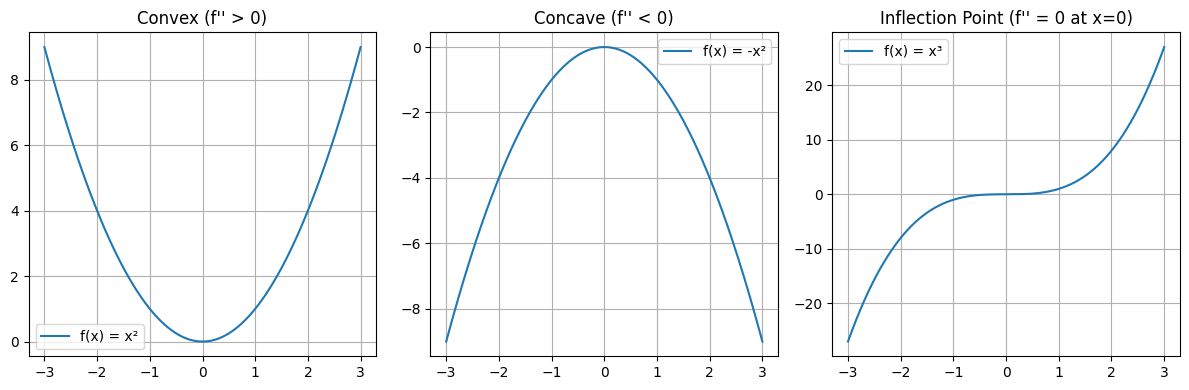

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 400)

# Convex (U-shape)
f1 = x**2

# Concave (n-shape)
f2 = -x**2

# Inflection point (change in curvature)
f3 = x**3

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, f1, label='f(x) = x²')
plt.title("Convex (f'' > 0)")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(x, f2, label='f(x) = -x²')
plt.title("Concave (f'' < 0)")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x, f3, label='f(x) = x³')
plt.title("Inflection Point (f'' = 0 at x=0)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


#### second derivative

In [2]:
def second_derivative(f, x, h=1e-5):
    return (f(x + h) - 2 * f(x) + f(x - h)) / h**2

# Test on f(x) = x² → f'' = 2
f = lambda x: x**2
print("Second derivative at x = 1:", second_derivative(f, 1))  # ≈ 2

# Test on f(x) = -x² → f'' = -2
f2 = lambda x: -x**2
print("Second derivative at x = 1:", second_derivative(f2, 1))  # ≈ -2


Second derivative at x = 1: 2.000002385926791
Second derivative at x = 1: -2.000002385926791


#### Use Case:
Visualize how convexity of the loss function (Mean Squared Error) helps in gradient descent optimization 
— and compute the second derivative (curvature) at a point.

##### Create a simple loss function: MSE for linear regression
Compute:
- First derivative (gradient)
- Second derivative (curvature)
- Visualize:
- Loss curve
- Slope (1st derivative)
- Curvature (2nd derivative)
- Show how second derivative helps in optimization


In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Simulate some data
np.random.seed(42)
x = np.linspace(0, 10, 50)
true_w = 2
y = true_w * x + np.random.randn(50) * 2

# Define loss function: MSE for 1D linear model y = wx
def mse_loss(w):
    y_pred = w * x
    return np.mean((y_pred - y) ** 2)


In [5]:
# First derivative (numerical gradient)
def first_derivative(f, w, h=1e-5):
    return (f(w + h) - f(w - h)) / (2 * h)

# Second derivative (numerical curvature)
def second_derivative(f, w, h=1e-5):
    return (f(w + h) - 2*f(w) + f(w - h)) / (h ** 2)


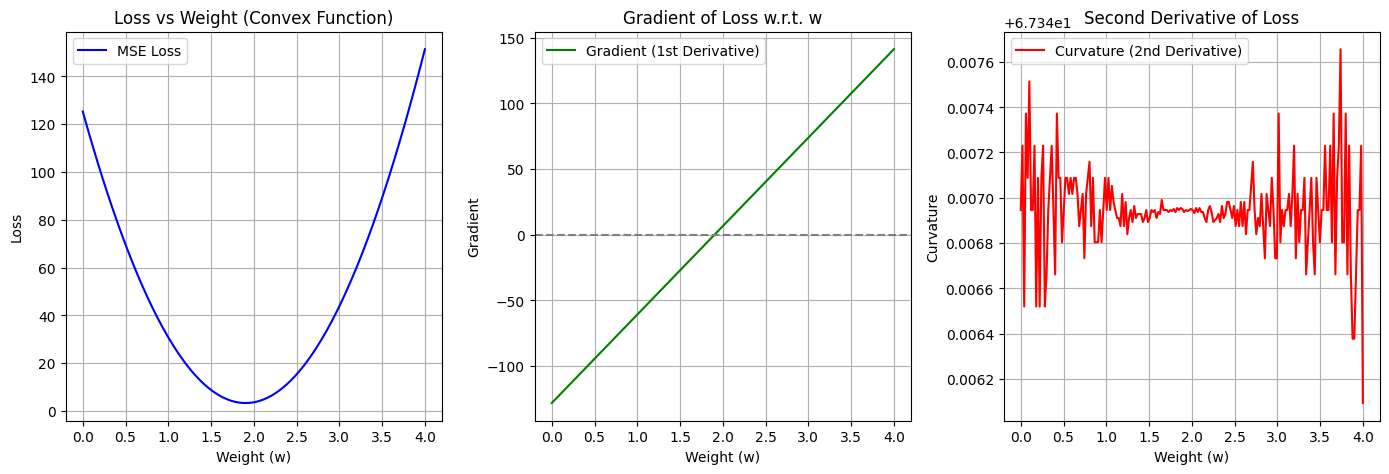

In [6]:
# Generate range of weights
w_values = np.linspace(0, 4, 200)
loss_values = np.array([mse_loss(w) for w in w_values])
gradients = np.array([first_derivative(mse_loss, w) for w in w_values])
curvatures = np.array([second_derivative(mse_loss, w) for w in w_values])

# Plot
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(w_values, loss_values, label='MSE Loss', color='blue')
plt.title("Loss vs Weight (Convex Function)")
plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Plot First Derivative (Gradient)
plt.subplot(1, 3, 2)
plt.plot(w_values, gradients, label="Gradient (1st Derivative)", color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Gradient of Loss w.r.t. w")
plt.xlabel("Weight (w)")
plt.ylabel("Gradient")
plt.grid(True)
plt.legend()

# Plot Second Derivative (Curvature)
plt.subplot(1, 3, 3)
plt.plot(w_values, curvatures, label="Curvature (2nd Derivative)", color='red')
plt.title("Second Derivative of Loss")
plt.xlabel("Weight (w)")
plt.ylabel("Curvature")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
